In [1]:
import numpy as np
from pathlib import Path
import fastplotlib as fpl
import pandas as pd
from decord import VideoReader
from abc import ABC, abstractmethod
from typing import *

Unable to find extension: VK_EXT_physical_device_drm


Image(value=b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHDR\x00\x00\x01,\x00\x00\x007\x08\x06\x00\x00\x00\xb6\x1bw\x99\x…

Valid,Device,Type,Backend,Driver
✅,AMD Radeon 780M (RADV PHOENIX),IntegratedGPU,Vulkan,Mesa 25.0.7-2~bpo12+1
✅ (default),NVIDIA RTX A1000 6GB Laptop GPU,DiscreteGPU,Vulkan,575.57.08
❗ limited,"llvmpipe (LLVM 15.0.6, 256 bits)",CPU,Vulkan,Mesa 25.0.7-2~bpo12+1 (LLVM 15.0.6)
❌,"AMD Radeon 780M (radeonsi, phoenix, LLVM 15.0.6, DRM 3.61, 6.12.57+deb12-amd64)",Unknown,OpenGL,4.6 (Core Profile) Mesa 25.0.7-2~bpo12+1


In [2]:
parent_path = Path("/home/kushal/data/kcenia/")

In [3]:
def vid_second_to_index(s: float) -> int:
    return vid_indexing.searchsorted(s)

def tracks_second_to_index(s: float) -> int:
    return df_tracks["times"].searchsorted(s)

In [4]:
df_tracks = pd.read_csv(parent_path.joinpath("video_data.csv"))
df_tracks

,nose_tip_x,nose_tip_y,nose_tip_likelihood,pupil_top_r_x,pupil_top_r_y,pupil_top_r_likelihood,pupil_top_r_x_ens_median,pupil_top_r_y_ens_median,pupil_top_r_x_ens_var,pupil_top_r_y_ens_var,...,tube_bottom_x,tube_bottom_y,tube_bottom_likelihood,tongue_end_l_x,tongue_end_l_y,tongue_end_l_likelihood,tongue_end_r_x,tongue_end_r_y,tongue_end_r_likelihood,times
0,167.842781,286.913076,0.999864,443.894814,190.173240,0.998643,444.052498,190.548458,0.113807,0.075323,...,293.920395,445.772614,0.999971,281.745491,410.380905,0.001576,283.634926,410.398018,0.001351,2.579200
1,167.842781,286.913076,0.999864,443.894966,190.173650,0.998643,444.052498,190.548458,0.113807,0.075323,...,293.920395,445.772614,0.999971,281.745491,410.380905,0.001576,283.634926,410.398018,0.001351,2.604800
2,167.842781,286.913076,0.999864,443.915987,190.191422,0.998643,444.052498,190.548458,0.113807,0.075323,...,293.920395,445.772614,0.999971,281.745491,410.380905,0.001576,283.634926,410.398018,0.001351,2.630400
3,162.909931,293.424446,0.997724,443.963149,190.231734,0.999108,443.924583,190.486732,0.095225,0.068660,...,293.660896,446.639214,0.999071,282.049431,411.219681,0.001381,284.632889,411.008743,0.001241,2.656000
4,164.736584,291.756172,0.993336,444.056465,190.301728,0.998958,443.986042,190.434261,0.106825,0.068595,...,293.693123,446.294495,0.999884,281.405090,410.951775,0.001358,283.811623,410.070747,0.001224,2.681700
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200264,179.857761,310.318012,0.926921,441.430499,187.671603,0.998886,441.231728,187.864689,0.096669,0.076924,...,294.012558,445.905571,0.999984,282.939896,411.287216,0.001462,284.103745,409.418373,0.001374,5134.258045
200265,167.375214,290.504356,0.963188,441.429144,187.634814,0.999135,441.278057,187.812428,0.092426,0.070794,...,293.741898,445.909035,0.999960,282.974686,411.244926,0.001457,284.845581,410.395554,0.001333,5134.283686
200266,167.725983,291.021839,0.996800,441.431580,187.595816,0.999472,441.208755,187.758507,0.100853,0.065544,...,292.409706,447.389526,0.999672,284.155411,411.187981,0.001471,283.402618,410.220284,0.001636,5134.309327
200267,167.725983,291.021839,0.996800,441.433312,187.576316,0.999472,441.208755,187.758507,0.100853,0.065544,...,292.409706,447.389526,0.999672,284.155411,411.187981,0.001471,283.402618,410.220284,0.001636,5134.334968


In [6]:
df_tracks.index.size

200269

In [7]:
set([c.split("_")[0] for c in df_tracks.columns])

{'nose', 'paw', 'pupil', 'times', 'tongue', 'tube'}

In [8]:
from itertools import chain

In [9]:
keypoints = [
    "nose_tip",
    "pupil_top_r",
    "pupil_bottom_r",
    "pupil_right_r",
    "pupil_left_r",
    "paw_l",
    "paw_r",
    "tongue_end_l",
    "tongue_end_r",
]

keypoints_cols = np.array([(f"{k}_x", f"{k}_y", f"{k}_likelihood") for k in keypoints]).flatten()
for k in keypoints_cols:
    if k not in df_tracks.columns:
        print(k)

In [10]:
np.column_stack([df_tracks["nose_tip_x"][50:100], df_tracks["nose_tip_y"][50:100]])

array([[166.60115433, 326.36621857],
       [166.5790062 , 326.29749298],
       [166.59462738, 326.26755524],
       [166.5694046 , 326.13886261],
       [165.95864487, 324.56661987],
       [165.92277527, 324.45320892],
       [166.00499344, 324.39343262],
       [165.37626648, 323.41609192],
       [165.34564209, 323.55264282],
       [165.16934204, 323.09661865],
       [162.51782227, 303.83456802],
       [167.66231537, 339.75151062],
       [161.10714722, 329.72454834],
       [165.57491302, 340.23025513],
       [165.10507584, 337.84264374],
       [163.20165253, 315.34876251],
       [167.10280609, 300.65746307],
       [170.61535645, 297.03971863],
       [167.3739624 , 291.23168564],
       [168.54373169, 288.28331375],
       [174.23193359, 285.33983231],
       [173.94360352, 276.30265045],
       [168.53238297, 277.00377083],
       [165.22519684, 287.11435509],
       [163.2495079 , 286.89777184],
       [161.82779312, 290.40311432],
       [165.02054214, 280.17184067],
 

In [11]:
df_trials = pd.read_csv(parent_path.joinpath("trials_data.csv"))
df_trials

,goCueTrigger_times,included,quiescencePeriod,stimOff_times,stimOffTrigger_times,stimOnTrigger_times,goCue_times,response_times,choice,stimOn_times,contrastLeft,contrastRight,feedback_times,feedbackType,rewardVolume,probabilityLeft,firstMovement_times
0,3.678400,True,0.693412,6.200200,6.145700,3.578300,3.698300,4.145600,-1.0,3.786400,0.000,NaN,4.175400,-1.0,0.0,0.5,4.086964
1,7.886400,True,0.419460,9.266900,9.221900,7.832500,7.916900,8.221800,1.0,7.886300,0.250,NaN,8.221900,1.0,1.5,0.5,8.145964
2,11.119700,True,0.558785,13.419500,13.371900,11.072700,11.150200,11.371800,1.0,11.119600,NaN,0.1250,11.399300,-1.0,0.0,0.5,11.279964
3,15.733500,True,0.410008,17.052900,17.007200,15.689900,15.760800,16.007100,1.0,15.733400,0.250,NaN,16.007200,1.0,1.5,0.5,15.919964
4,19.316700,True,0.582946,20.636000,20.591800,19.274100,19.346200,19.591700,1.0,19.316600,1.000,NaN,19.591800,1.0,1.5,0.5,19.510964
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
950,5040.976099,False,0.428614,5042.395299,5042.331699,5040.916999,5041.006199,5041.331599,1.0,5040.975999,0.250,NaN,5041.331699,1.0,1.5,0.8,5041.223964
951,5044.309399,False,0.648009,5047.745399,5047.684499,5044.243399,5044.339599,5046.684399,-1.0,5044.309299,NaN,0.0625,5046.684499,1.0,1.5,0.8,5046.492964
952,5049.459298,False,0.440100,5050.842498,5050.786098,5049.394298,5049.489198,5049.785998,1.0,5049.459198,1.000,NaN,5049.786098,1.0,1.5,0.8,5049.668964
953,5053.028698,False,0.427945,5100.510898,5100.458198,5052.974398,5053.058698,5098.458098,-1.0,5053.028598,0.000,NaN,5098.489198,-1.0,0.0,0.8,5098.376964


In [12]:
from fastplotlib.widgets.nd_widget._nd_positions import NDPositionsProcessor, NDPositions

In [13]:
class NDBehaviorTracksProcessor(NDPositionsProcessor):
    def __init__(
            self,
            data: tuple[pd.DataFrame, list[str]],
            max_display_datapoints: int = 1_000,
            **kwargs,
    ):
        self._keypoints = data[1]
        data = data[0]

        self._keypoints_cols = np.array(
            [(f"{k}_x", f"{k}_y", f"{k}_likelihood") for k in self.keypoints]
        ).flatten()

        super().__init__(
            data=data,
            max_display_datapoints=max_display_datapoints,
            **kwargs,
        )

    @property
    def data(self) -> pd.DataFrame:
        return self._data

    def _validate_data(self, data: pd.DataFrame):
        if not isinstance(data, pd.DataFrame):
            raise TypeError

        return data

    @property
    def keypoints(self) -> list[str]:
        return self._keypoints

    @property
    def multi(self) -> bool:
        return True

    @multi.setter
    def multi(self, *args):
        pass

    @property
    def shape(self) -> tuple[int, ...]:
        # n_keypoints, n_timepoints, 2
        return len(self.keypoints), self.data.index.size, 2

    @property
    def ndim(self) -> int:
        return len(self.shape)

    @property
    def n_slider_dims(self) -> int:
        return 1

    def format_tooltip(self, n: int, p: int):
        k = self.keypoints[n]
        # datapoint index w.r.t. full data
        p += self._slices[-1].start
        return str(self.data[f"{k}_likelihood"][p])

    def get(self, indices: tuple[float | int, ...]) -> np.ndarray:
        # assume no additional slider dims, only time slider dim
        self._slices = self._get_dw_slices(indices)

        gdata_shape = len(self.keypoints), self._slices[-1].stop - self._slices[-1].start, 2
        gdata = np.zeros(shape=gdata_shape, dtype=np.float32)

        for i, k in enumerate(self.keypoints):
            gdata[i] = np.column_stack([self.data[f"{k}_x"][self._slices[-1]], self.data[f"{k}_y"][self._slices[-1]]])

        return gdata

In [14]:
slice(10, 100).stop - slice(10, 100).start

90

In [15]:
ndbp = NDBehaviorTracksProcessor(
    data=(df_tracks, keypoints),
    display_window=5.0,
    index_mappings=(tracks_second_to_index,)
)

In [16]:
df_tracks.index.size

200269

In [17]:
ndp1 = NDPositions(
    data=(df_tracks, keypoints),
    processor=NDBehaviorTracksProcessor, 
    graphic=fpl.ScatterCollection, 
    display_window=5,
    index_mappings=(tracks_second_to_index,)
)

ndp2 = NDPositions(
    data=(df_tracks, keypoints),
    processor=NDBehaviorTracksProcessor, 
    graphic=fpl.LineCollection, 
    display_window=5,
    index_mappings=(tracks_second_to_index,)
)

In [18]:
from ipywidgets import FloatSlider, VBox, Layout

In [19]:
df_tracks["times"].values[-1]

np.float64(5134.36060925641)

In [20]:
nd_arrays = [ndp1, ndp2]

In [21]:
def update_dw(change):
    for ndp in nd_arrays:
        ndp.display_window = change["new"]
    # fig[0, 0].auto_scale()

slider_dw = FloatSlider(
    min=0, max=30.0, 
    value=df_tracks["times"][0], description="disp window", layout=Layout(width="600px")
)

slider_dw.observe(update_dw, "value")

def update_t(change):
    for ndp in nd_arrays:
        ndp.indices = (change["new"],)
    # fig[0, 0].auto_scale()

slider = FloatSlider(
    min=df_tracks["times"][0], max=df_tracks["times"].values[-1], value=0, 
    description="index", layout=Layout(width="600px")
)
slider.observe(update_t, "value")

RFBOutputContext()

JupyterRenderCanvas(css_height='300.0px', css_width='500.0px')
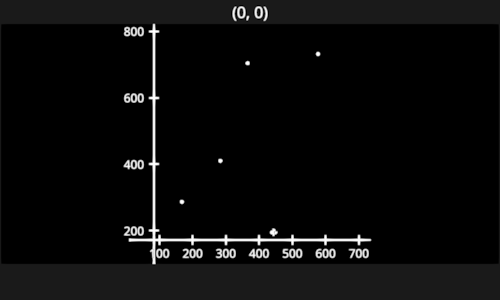

In [22]:
fig = fpl.Figure()

fig[0, 0].add_graphic(ndp1.graphic)
fig[0, 0].add_graphic(ndp2.graphic)

fig.show()

In [28]:
ndp1.graphic.graphics

array([ScatterGraphic, ScatterGraphic, ScatterGraphic, ScatterGraphic,
       ScatterGraphic, ScatterGraphic, ScatterGraphic, ScatterGraphic,
       ScatterGraphic], dtype=object)

In [29]:
np.argwhere(ndp1.graphic.graphics == ndp1.graphic[2]).item()

2

In [30]:
ndp1.graphic.add_event_handler(lambda ev: print(ev.graphic), "click")

In [31]:
ndp1.processor.window_funcs = (np.std,)
ndp1.processor.window_sizes = (11,)

In [32]:
ndp1.graphic.cmap = "tab10"

In [33]:
for g in ndp1.graphic:
    g.sizes = 10
    g.visible = True

In [34]:
VBox([slider_dw, slider])

In [31]:
for g in ndp2.graphic:
    g.color_mode = "vertex"
    g.cmap = "viridis"
    g.visible = False